# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 2. 

In [1]:

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

# Task 2 - EBM-NLP

This dataset is provided at https://github.com/bepnye/EBM-NLP and a copy has been made available in this repository for convenience. The data will need to be unzipped:

In [2]:
import tarfile
import os

# path_tofile = "./ebm_nlp_2_00.tar.gz"
# extract_directory = os.path.dirname(path_tofile)

# if tarfile.is_tarfile(path_tofile):
#     with tarfile.open(path_tofile) as f:
#         f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


The data contains text documents that are annotated for mentions of participants, interventions and outcomes (PIO) in medical research. For each entity type, P, I, or O, there is a slightly different set of documents in the training and test set. Most of the documents are identical, but each type has a few extra documents. So, let's deal with each type separately for now.

To load the text documents, we first make a list of the document IDs for one entity type (P, I or O):
根据标签类型和数据划分，找到有哪些带标注的文档 ID，并统计 train/test 各有多少篇

In [3]:
from pathlib import Path

DATA_DIR = Path("./ebm_nlp_2_00")

docs_dir = DATA_DIR / "documents"

def get_doc_ids(split="train", label_type="participants"):
    """ 
    split: 'train' or 'test' 
    """

    if split == "test":
        split = "test/gold"

    train_dir = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "hierarchical_labels"
        / label_type  # assuming that the split is the same for all entity types, we can just look at one of them
        / split
    )
    
    doc_ids = [p.stem.split(".")[0] for p in train_dir.glob("*.AGGREGATED.ann")]
    print(doc_ids)
    return sorted(doc_ids)

doc_ids_p = get_doc_ids("train", "participants")
test_doc_ids_p = get_doc_ids("test", "participants")

print(f"Number of documents in train split for participants: {len(doc_ids_p)}")
print(f"Number of documents in test split for participants: {len(test_doc_ids_p)}")


['10036953', '10037531', '10052279', '10071998', '10073522', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10373718', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10437192', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463377', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10

Now, we can get the annotations for the first entity type:
This section is actually reading in the corresponding annotation file for a certain document.
The previous code merely identified which doc_ids were present; this section, however, reads in the contents of the .AGGREGATED.ann files corresponding to these doc_ids.
In essence: it reads in the token-level annotation files for each document, forming a data structure where "each document corresponds to a list of labels".

In [4]:
def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    """
    label_type: 'participants', 'interventions', or 'outcomes'
    split: 'train' or 'test' 
    """
    if split == "test":
        split = "test/gold"

    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"
    
    if not ann_path.exists():
        print(ann_path, "does not exist!")
        return None
    
    with open(ann_path, "r", encoding="utf-8") as f:
        labels = [line.strip() for line in f]
    
    return labels

def load_labels(doc_ids, label_type="participants", split="train"):
    labels = []
    for doc_id in doc_ids:
        doc_labels = load_labels_for_doc(doc_id, label_type, split)
        if doc_labels is not None:
            labels.append(doc_labels)
    return labels

participants_labels = load_labels(doc_ids_p, "participants", split="train")

print(f"Length of participants_labels: {len(participants_labels)}")

test_participants_labels = load_labels(test_doc_ids_p, "participants", split="test")
print(f"Length of test_participants_labels: {len(test_participants_labels)}")

sample = 123
print("Document ID:", doc_ids_p[sample])
print(f"Participants label example for doc {doc_ids_p[sample]}:")
print(participants_labels[sample])

Length of participants_labels: 4609
Length of test_participants_labels: 189
Document ID: 10674680
Participants label example for doc 10674680:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '4', '4', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '

In [5]:
from itertools import chain
import numpy as np

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset 
print(np.unique(list(all_labels)))

['0' '1' '2' '3' '4']


Let's look at what labels there are for Participants. The code above shows there are four values: 0 corresponds to 'outside' but 1-4 all indicate tokens that form an entity span. Each number is a level in a hierarchy of specificity. To start with let's not worry about this 'hierarchy'. We can instead just turn the labels into simple BIO (Beginning of a span, Inside a span, and Outside a span) tags.


In [6]:
def hierarchical_to_bio(tags):
    """
    Convert EBM-NLP hierarchical labels (0–4) to flat BIO tags.

    Parameters
    ----------
    tags : list[int]
        A list of hierarchical labels for a single document.

    Returns
    -------
    list[str]
        BIO tags ("O", "B", "I").
    """

    bio = []
    prev = 0

    for t in tags:
        t = int(t)  # ensure it's an integer
        if t == 0:
            bio.append("O")
        else:
            if prev == 0:
                bio.append("B")
            else:
                bio.append("I")

        prev = t
        

    return bio

def convert_all_labels_to_bio(labels):
    for i, doc_labels in enumerate(labels):
        labels[i] = hierarchical_to_bio(doc_labels)
    return labels

participants_labels = convert_all_labels_to_bio(participants_labels)
test_participants_labels = convert_all_labels_to_bio(test_participants_labels)

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['B' 'I' 'O']


So far, we've loaded the document IDs for participants and the corresponding labels. Now, let's load the documents themselves. They are already tokenised so that the labels match up with the tokens:


In [7]:
def load_document(doc_id):
    doc_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(doc_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def load_documents(doc_ids):
    documents = []
    for doc_id in doc_ids:
        doc = load_document(doc_id)
        documents.append(doc)
    return documents

participants_tokens = load_documents(doc_ids_p)
test_participants_tokens = load_documents(test_doc_ids_p)

# inspect a random element
print("Document ID:", doc_ids_p[sample])
print(f"Tokenised document example for doc {doc_ids_p[sample]}:")
print(participants_tokens[sample])


Document ID: 10674680
Tokenised document example for doc 10674680:
['Assessment', 'of', 'therapeutic', 'response', 'of', 'Plasmodium', 'falciparum', 'to', 'chloroquine', 'and', 'sulfadoxine-pyrimethamine', 'in', 'an', 'area', 'of', 'low', 'malaria', 'transmission', 'in', 'Colombia', '.', 'Although', 'chloroquine', '(', 'CQ', ')', 'resistance', 'was', 'first', 'reported', 'in', 'Colombia', 'in', '1961', 'and', 'sulfadoxine-pyrimethamine', '(', 'SP', ')', 'resistance', 'in', '1981', ',', 'the', 'frequency', 'of', 'treatment', 'failures', 'to', 'these', 'drugs', 'in', 'Colombia', 'is', 'unclear', '.', 'A', 'modified', 'World', 'Health', 'Organization', '14-day', 'in', 'vivo', 'drug', 'efficacy', 'test', 'for', 'uncomplicated', 'Plasmodium', 'falciparum', 'malaria', 'in', 'areas', 'with', 'intense', 'malaria', 'transmission', 'was', 'adapted', 'to', 'reflect', 'the', 'clinical', 'and', 'epidemiologic', 'features', 'of', 'a', 'low-intensity', 'malaria', 'transmission', 'area', 'in', 'the', 

### Interventions

In [8]:
doc_ids_i = get_doc_ids("train", "interventions")
test_doc_ids_i = get_doc_ids("test", "interventions")

print(f"Number of documents in train split for interventions: {len(doc_ids_i)}")
print(f"Number of documents in test split for interventions: {len(test_doc_ids_i)}")

interventions_tokens = load_documents(doc_ids_i)
test_interventions_tokens = load_documents(test_doc_ids_i)

['10036953', '10037531', '10052279', '10071998', '10073522', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10373718', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10

In [9]:
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
print(f"Length of interventions_labels: {len(interventions_labels)}")

test_interventions_labels = load_labels(test_doc_ids_i, "interventions", split="test")
print(f"Length of test_interventions_labels: {len(test_interventions_labels)}")

interventions_labels = convert_all_labels_to_bio(interventions_labels)
test_interventions_labels = convert_all_labels_to_bio(test_interventions_labels)

Length of interventions_labels: 4746
Length of test_interventions_labels: 187


### Outcomes

In [10]:
doc_ids_o = get_doc_ids("train", "outcomes")
test_doc_ids_o = get_doc_ids("test", "outcomes")

print(f"Number of documents in train split for outcomes: {len(doc_ids_o)}")
print(f"Number of documents in test split for outcomes: {len(test_doc_ids_o)}")

outcomes_tokens = load_documents(doc_ids_o)
test_outcomes_tokens = load_documents(test_doc_ids_o)

['10036953', '10037531', '10052279', '10071998', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463377', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10517189', '10

In [11]:
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
print(f"Length of outcomes_labels: {len(outcomes_labels)}")

test_outcomes_labels = load_labels(test_doc_ids_o, "outcomes", split="test")   
print(f"Length of test_outcomes_labels: {len(test_outcomes_labels)}")

outcomes_labels = convert_all_labels_to_bio(outcomes_labels)
test_outcomes_labels = convert_all_labels_to_bio(test_outcomes_labels)


Length of outcomes_labels: 4681
Length of test_outcomes_labels: 190


In [12]:
print(f"Intersection of train doc IDs across entity types: {len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))}")
print(f"Intersection of test doc IDs across entity types: {len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))}")
print(f"Documents that are different across entity types in train split: {len((set(doc_ids_p) | set(doc_ids_i) | set(doc_ids_o)) - (set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(test_doc_ids_p) | set(test_doc_ids_i) | set(test_doc_ids_o)) - (set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))}")


print(f"Test examples of the participants type that are in other entity types' training splits: {set(test_doc_ids_p) & (set(doc_ids_i) | set(doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(test_doc_ids_i) & (set(doc_ids_p) | set(doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(test_doc_ids_o) & (set(doc_ids_p) | set(doc_ids_i))}")

Intersection of train doc IDs across entity types: 4457
Intersection of test doc IDs across entity types: 184
Documents that are different across entity types in train split: 344
Documents that are different across entity types in test split: 7
Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


Task2 Part1

In [13]:
def load_tokens_for_doc(doc_id):
    token_path = docs_dir / f"{doc_id}.tokens"
    
    if not token_path.exists():
        print(token_path, "does not exist!")
        return None
    
    with open(token_path, "r", encoding="utf-8") as f:
        tokens = [line.strip() for line in f]
    
    return tokens

sample = 222
sample_doc_id = doc_ids_p[sample]

sample_tokens = load_tokens_for_doc(sample_doc_id)
print("Doc ID:", sample_doc_id)
print("Number of tokens:", len(sample_tokens))
print(sample_tokens[:50])

print("Tokens:", len(sample_tokens))
print("Labels:", len(participants_labels[sample]))

Doc ID: 11069570
Number of tokens: 356
['Probiotics', 'in', 'the', 'management', 'of', 'atopic', 'eczema', '.', 'BACKGROUND', 'Over', 'the', 'last', 'two', 'decades', 'the', 'incidence', 'of', 'allergic', 'diseases', 'has', 'increased', 'in', 'industrialized', 'countries', ',', 'and', 'consequently', 'new', 'approaches', 'have', 'to', 'be', 'explored', '.', 'OBJECTIVE', 'The', 'potential', 'of', 'probiotics', 'to', 'control', 'allergic', 'inflammation', 'at', 'an', 'early', 'age', 'was', 'assessed', 'in']
Tokens: 356
Labels: 356


In [14]:
for tok, lab in list(zip(sample_tokens, participants_labels[sample]))[:50]:
    print(tok, lab)

Probiotics O
in O
the O
management O
of O
atopic B
eczema I
. I
BACKGROUND O
Over O
the O
last O
two O
decades O
the O
incidence O
of O
allergic O
diseases O
has O
increased O
in O
industrialized O
countries O
, O
and O
consequently O
new O
approaches O
have O
to O
be O
explored O
. O
OBJECTIVE O
The O
potential O
of O
probiotics O
to O
control O
allergic B
inflammation I
at I
an I
early I
age I
was O
assessed O
in O


In [15]:
def tokens_to_text(tokens):
    return " ".join(tokens)

sample_text = tokens_to_text(sample_tokens)
print(sample_text[:1000])

Probiotics in the management of atopic eczema . BACKGROUND Over the last two decades the incidence of allergic diseases has increased in industrialized countries , and consequently new approaches have to be explored . OBJECTIVE The potential of probiotics to control allergic inflammation at an early age was assessed in a randomized double-blind placebo-controlled study . METHODS A total of 27 infants , mean age 4.6 months , who manifested atopic eczema during exclusive breast-feeding and who have had no exposure to any infant or substitute formula were weaned to probiotic-supplemented , Bifidobacterium lactis Bb-12 or Lactobacillus strain GG ( ATCC 53103 ) , extensively hydrolysed whey formulas or to the same formula without probiotics . The extent and severity of atopic eczema , the growth and nutrition of infants , and concentrations of circulating cytokines/chemokines and soluble cell surface adhesion molecules in serum and methyl-histamine and eosinophilic protein X in urine were d

In [16]:
import nltk
from nltk.tokenize import sent_tokenize

def split_into_sentences(tokens):
    text = " ".join(tokens)
    sentences = sent_tokenize(text)
    return sentences

sample_sentences = split_into_sentences(sample_tokens)
print("Number of sentences:", len(sample_sentences))
for i, s in enumerate(sample_sentences[:5]):
    print(f"[{i}] {s}")

Number of sentences: 12
[0] Probiotics in the management of atopic eczema .
[1] BACKGROUND Over the last two decades the incidence of allergic diseases has increased in industrialized countries , and consequently new approaches have to be explored .
[2] OBJECTIVE The potential of probiotics to control allergic inflammation at an early age was assessed in a randomized double-blind placebo-controlled study .
[3] METHODS A total of 27 infants , mean age 4.6 months , who manifested atopic eczema during exclusive breast-feeding and who have had no exposure to any infant or substitute formula were weaned to probiotic-supplemented , Bifidobacterium lactis Bb-12 or Lactobacillus strain GG ( ATCC 53103 ) , extensively hydrolysed whey formulas or to the same formula without probiotics .
[4] The extent and severity of atopic eczema , the growth and nutrition of infants , and concentrations of circulating cytokines/chemokines and soluble cell surface adhesion molecules in serum and methyl-histamin

The current labels are at the token level, but what needs to be clustered is at the sentence level.
Therefore, the token labels must be aggregated into sentence labels. 
The simplest and most feasible method is:
First, combine the tokens into a complete text.
Then, split it into sentences.
Next, find a way to map each sentence back to its original token range.
Determine which label appears the most in this sentence.
Use the majority label as the gold label for this sentence. 
Here is a simpler version:
First, conduct an exploration of a single label_type, such as "participants".
This way, we can initially answer:
Will the sentences related to the "participants" information naturally group together?
That is to say, it is not necessary to achieve P/I/O separation simultaneously in one step now.
We can first do this for one field:
If a sentence contains many "participants" label tokens, mark it as "participants", otherwise mark it as "other"

The idea is: 
Perform rough sentence segmentation based on the periods, question marks, and exclamation marks in the tokens.
At the same time, assign the corresponding token labels to the same sentence.
Then give this sentence a label.
Complete encapsulation:

In [17]:
#Token-based splitting function
def split_tokens_into_sentences(tokens, labels):
    sentences = []
    current_tokens = []
    current_labels = []
    
    end_punct = {".", "!", "?"}
    
    for tok, lab in zip(tokens, labels):
        current_tokens.append(tok)
        current_labels.append(lab)
        
        if tok in end_punct:
            sentences.append((current_tokens, current_labels))
            current_tokens = []
            current_labels = []
    
    if current_tokens:
        sentences.append((current_tokens, current_labels))
    
    return sentences

In [18]:
#Sentence-level Label Function
def assign_sentence_label(token_labels, target_name, positive_label_values=None, min_pos_count=2):
    if positive_label_values is None:
        positive_label_values = {"B", "I"}
    
    pos_count = sum(l in positive_label_values for l in token_labels)
    
    if pos_count >= min_pos_count:
        return target_name
    else:
        return "other"

In [19]:
def build_sentence_dataframe(doc_ids, all_doc_labels, target_name, min_pos_count=2):
    rows = []
    
    for doc_id, doc_labels in zip(doc_ids, all_doc_labels):
        tokens = load_tokens_for_doc(doc_id)
        
        if tokens is None:
            continue
        
        if len(tokens) != len(doc_labels):
            print(f"Length mismatch for {doc_id}: tokens={len(tokens)}, labels={len(doc_labels)}")
            continue
        
        sentence_units = split_tokens_into_sentences(tokens, doc_labels)
        
        for sent_toks, sent_labs in sentence_units:
            sent_text = " ".join(sent_toks).strip()
            
            if not sent_text:
                continue
            
            gold_label = assign_sentence_label(
                token_labels=sent_labs,
                target_name=target_name,
                positive_label_values={"B", "I"},
                min_pos_count=min_pos_count
            )
            
            rows.append({
                "doc_id": doc_id,
                "sentence_text": sent_text,
                "gold_label": gold_label,
                "positive_token_count": sum(l in {"B", "I"} for l in sent_labs),
                "sentence_length": len(sent_labs)
            })
    
    df_sent = pd.DataFrame(rows)
    return df_sent

In [20]:
df_sent_p = build_sentence_dataframe(
    doc_ids=doc_ids_p,
    all_doc_labels=participants_labels,
    target_name="participants",
    min_pos_count=2
)

print(df_sent_p.head())
print(df_sent_p["gold_label"].value_counts())
print("Number of sentences:", len(df_sent_p))

     doc_id                                      sentence_text    gold_label  \
0  10036953  [ Triple therapy regimens involving H2 blockad...         other   
1  10036953  Comparison of ranitidine and lansoprazole in s...         other   
2  10036953  To evaluate the efficacy and safety of two 1-w...  participants   
3  10036953  The drug combination and administration period...         other   
4  10036953  The ranitidine group received RNT 300 mg , CAM...         other   

   positive_token_count  sentence_length  
0                     0               15  
1                     0               15  
2                     4               53  
3                     0               27  
4                     0               20  
gold_label
other           40262
participants     9186
Name: count, dtype: int64
Number of sentences: 49448


In [21]:
from sentence_transformers import SentenceTransformer
#get the embedding
def compute_sentence_embeddings(df_sent, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)
    X = model.encode(df_sent["sentence_text"].tolist(), show_progress_bar=True)
    return X, model

In [22]:
X_p, emb_model = compute_sentence_embeddings(df_sent_p)
print(X_p.shape)

Batches:   0%|          | 0/1546 [00:00<?, ?it/s]

(49448, 384)


K-means

In [23]:
from sklearn.cluster import KMeans

def run_kmeans_analysis(df_sent, X, k_values=[2, 3, 4, 5], random_state=42):
    summaries = {}
    
    for k in k_values:
        colname = f"cluster_kmeans_{k}"
        
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        df_sent[colname] = kmeans.fit_predict(X)
        
        summary = pd.crosstab(
            df_sent[colname],
            df_sent["gold_label"],
            normalize="index"
        )
        
        summaries[k] = summary
        
        print(f"\n===== k = {k} =====")
        print(summary)
    
    return df_sent, summaries

In [24]:
df_sent_p, kmeans_summaries_p = run_kmeans_analysis(df_sent_p, X_p, k_values=[2,3,4,5])


===== k = 2 =====
gold_label           other  participants
cluster_kmeans_2                        
0                 0.816539      0.183461
1                 0.812857      0.187143

===== k = 3 =====
gold_label           other  participants
cluster_kmeans_3                        
0                 0.796038      0.203962
1                 0.848627      0.151373
2                 0.789798      0.210202

===== k = 4 =====
gold_label           other  participants
cluster_kmeans_4                        
0                 0.796374      0.203626
1                 0.883235      0.116765
2                 0.787522      0.212478
3                 0.787677      0.212323

===== k = 5 =====
gold_label           other  participants
cluster_kmeans_5                        
0                 0.775862      0.224138
1                 0.714578      0.285422
2                 0.849488      0.150512
3                 0.874711      0.125289
4                 0.802157      0.197843


HAC(Sampling)

In [25]:
from sklearn.cluster import AgglomerativeClustering

def run_hac_analysis(df_sent, X, n_clusters=2, sample_size=None, random_state=42):
    if sample_size is not None and sample_size < len(df_sent):
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(df_sent), size=sample_size, replace=False)
        
        df_sub = df_sent.iloc[idx].copy()
        X_sub = X[idx]
    else:
        df_sub = df_sent.copy()
        X_sub = X
    
    hac = AgglomerativeClustering(n_clusters=n_clusters)
    df_sub["cluster_hac"] = hac.fit_predict(X_sub)
    
    hac_summary = pd.crosstab(
        df_sub["cluster_hac"],
        df_sub["gold_label"],
        normalize="index"
    )
    
    print(hac_summary)
    return df_sub, hac_summary

In [26]:
df_hac_p, hac_summary_p = run_hac_analysis(df_sent_p, X_p, n_clusters=2, sample_size=3000)

gold_label      other  participants
cluster_hac                        
0            0.799199      0.200801
1            0.814324      0.185676


PCA

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def add_pca_coordinates(df_sent, X, random_state=42):
    pca = PCA(n_components=2, random_state=random_state)
    X_2d = pca.fit_transform(X)
    
    df_sent = df_sent.copy()
    df_sent["pca1"] = X_2d[:, 0]
    df_sent["pca2"] = X_2d[:, 1]
    
    return df_sent, pca

gold label pic

In [28]:
def plot_by_gold_label(df_sent, title="Sentence embeddings coloured by gold label"):
    plt.figure(figsize=(8, 6))
    
    for lab in df_sent["gold_label"].unique():
        subset = df_sent[df_sent["gold_label"] == lab]
        plt.scatter(subset["pca1"], subset["pca2"], label=lab, alpha=0.5)
    
    plt.legend()
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

pic based on cluster

In [29]:
def plot_by_cluster(df_sent, cluster_col, title="Sentence embeddings coloured by cluster"):
    plt.figure(figsize=(8, 6))
    
    for c in sorted(df_sent[cluster_col].unique()):
        subset = df_sent[df_sent[cluster_col] == c]
        plt.scatter(subset["pca1"], subset["pca2"], label=f"cluster {c}", alpha=0.5)
    
    plt.legend()
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

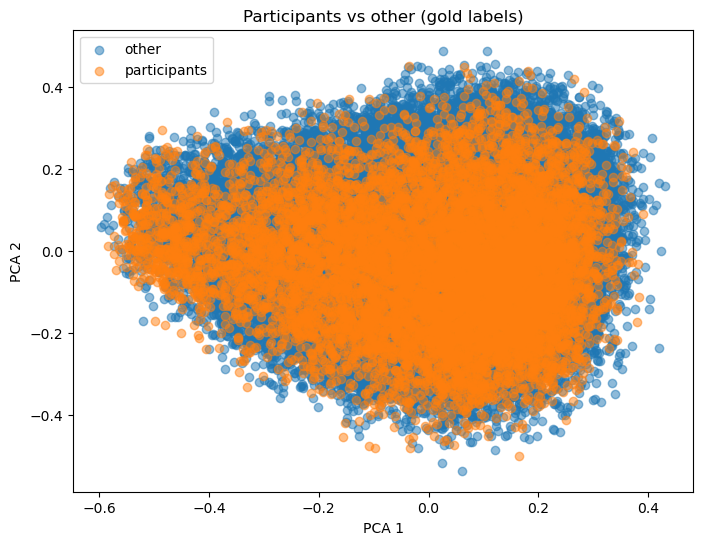

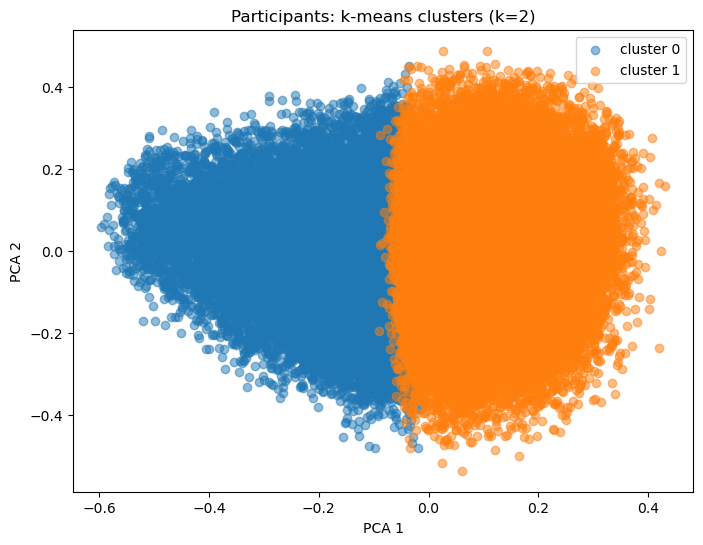

In [30]:
df_sent_p, pca_model_p = add_pca_coordinates(df_sent_p, X_p)

plot_by_gold_label(df_sent_p, title="Participants vs other (gold labels)")
plot_by_cluster(df_sent_p, "cluster_kmeans_2", title="Participants: k-means clusters (k=2)")

In [31]:
#Overall process
def run_field_clustering_pipeline(
    doc_ids,
    all_doc_labels,
    target_name,
    min_pos_count=2,
    embedding_model_name="all-MiniLM-L6-v2",
    k_values=[2,3,4,5],
    hac_sample_size=3000,
    random_state=42
):
    print(f"\n========== Running pipeline for: {target_name} ==========")
    
    df_sent = build_sentence_dataframe(
        doc_ids=doc_ids,
        all_doc_labels=all_doc_labels,
        target_name=target_name,
        min_pos_count=min_pos_count
    )
    
    print("\nGold label counts:")
    print(df_sent["gold_label"].value_counts())
    
    X, model = compute_sentence_embeddings(df_sent, model_name=embedding_model_name)
    
    df_sent, kmeans_summaries = run_kmeans_analysis(
        df_sent=df_sent,
        X=X,
        k_values=k_values,
        random_state=random_state
    )
    
    df_hac, hac_summary = run_hac_analysis(
        df_sent=df_sent,
        X=X,
        n_clusters=2,
        sample_size=hac_sample_size,
        random_state=random_state
    )
    
    df_sent, pca_model = add_pca_coordinates(df_sent, X, random_state=random_state)
    
    plot_by_gold_label(
        df_sent,
        title=f"{target_name}: sentence embeddings coloured by gold label"
    )
    
    if f"cluster_kmeans_2" in df_sent.columns:
        plot_by_cluster(
            df_sent,
            cluster_col="cluster_kmeans_2",
            title=f"{target_name}: sentence embeddings coloured by k-means cluster (k=2)"
        )
    
    return {
        "df_sent": df_sent,
        "X": X,
        "embedding_model": model,
        "kmeans_summaries": kmeans_summaries,
        "df_hac": df_hac,
        "hac_summary": hac_summary,
        "pca_model": pca_model
    }


========== Running pipeline for: participants ==========

Gold label counts:
gold_label
other           40262
participants     9186
Name: count, dtype: int64


Batches:   0%|          | 0/1546 [00:00<?, ?it/s]


===== k = 2 =====
gold_label           other  participants
cluster_kmeans_2                        
0                 0.816757      0.183243
1                 0.812726      0.187274

===== k = 3 =====
gold_label           other  participants
cluster_kmeans_3                        
0                 0.847740      0.152260
1                 0.789675      0.210325
2                 0.796829      0.203171

===== k = 4 =====
gold_label           other  participants
cluster_kmeans_4                        
0                 0.787746      0.212254
1                 0.796535      0.203465
2                 0.787384      0.212616
3                 0.883115      0.116885

===== k = 5 =====
gold_label           other  participants
cluster_kmeans_5                        
0                 0.801948      0.198052
1                 0.775667      0.224333
2                 0.849701      0.150299
3                 0.713156      0.286844
4                 0.874840      0.125160
gold_label      other 

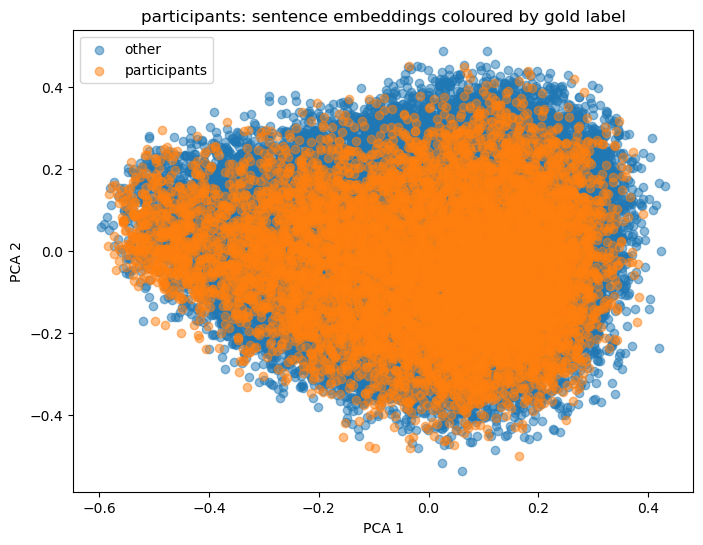

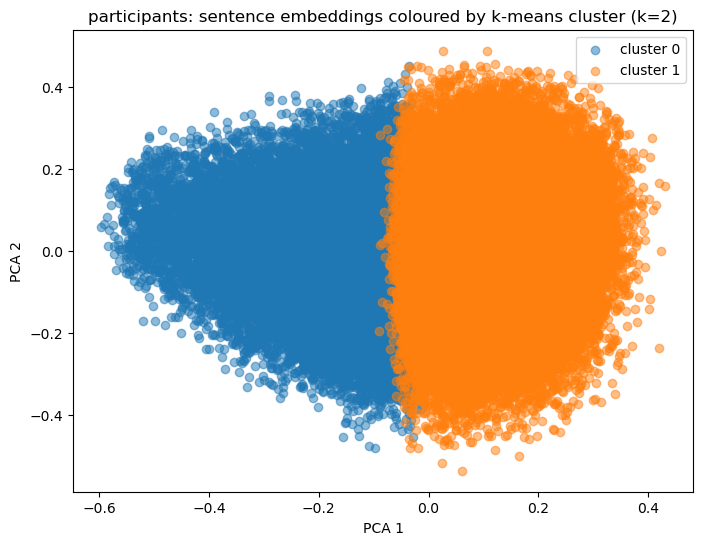

In [32]:
participants_results = run_field_clustering_pipeline(
    doc_ids=doc_ids_p,
    all_doc_labels=participants_labels,
    target_name="participants",
    min_pos_count=2,
    k_values=[2,3,4,5],
    hac_sample_size=3000,
    random_state=26
)

['10036953', '10037531', '10052279', '10071998', '10073522', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10373718', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10

Batches:   0%|          | 0/1590 [00:00<?, ?it/s]


===== k = 2 =====
gold_label        interventions     other
cluster_kmeans_2                         
0                      0.227332  0.772668
1                      0.349372  0.650628

===== k = 3 =====
gold_label        interventions     other
cluster_kmeans_3                         
0                      0.409661  0.590339
1                      0.266910  0.733090
2                      0.222316  0.777684

===== k = 4 =====
gold_label        interventions     other
cluster_kmeans_4                         
0                      0.204022  0.795978
1                      0.293484  0.706516
2                      0.461583  0.538417
3                      0.262524  0.737476

===== k = 5 =====
gold_label        interventions     other
cluster_kmeans_5                         
0                      0.360953  0.639047
1                      0.187278  0.812722
2                      0.282758  0.717242
3                      0.258664  0.741336
4                      0.452785  0.547215


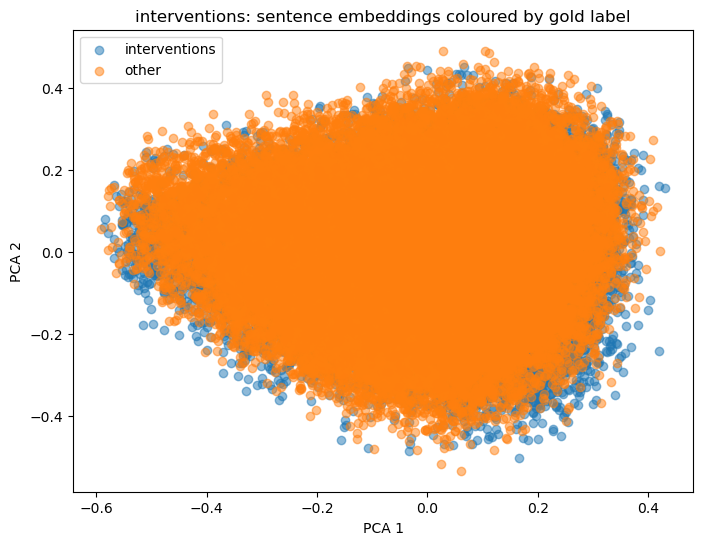

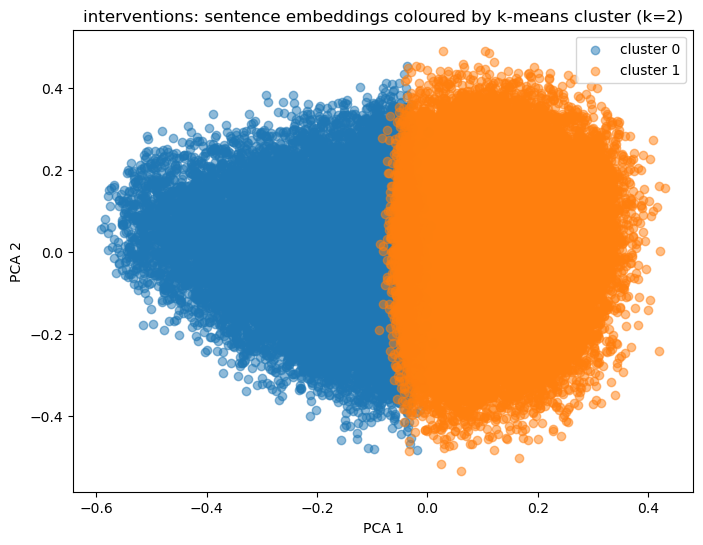

In [33]:
doc_ids_i = get_doc_ids("train", "interventions")
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
interventions_labels = convert_all_labels_to_bio(interventions_labels)

all_i_labels = list(chain(*interventions_labels))
print(np.unique(all_i_labels))

interventions_results = run_field_clustering_pipeline(
    doc_ids=doc_ids_i,
    all_doc_labels=interventions_labels,
    target_name="interventions",
    min_pos_count=2,
    k_values=[2,3,4,5],
    hac_sample_size=3000,
    random_state=26
)

['10036953', '10037531', '10052279', '10071998', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579', '10089089', '10091821', '10093945', '10094243', '10097996', '10100592', '10148879', '10155556', '10172265', '10188144', '10190267', '10194485', '10195003', '10197379', '10200837', '10201101', '10203382', '10207709', '10208073', '10209728', '10211492', '10213233', '10213554', '10223244', '10224577', '10225743', '10230191', '10235220', '10337083', '10337433', '10337657', '10337847', '10338217', '10340153', '10348763', '10352330', '10352397', '10355394', '10356632', '10360656', '10361382', '10361648', '10374155', '10379020', '10380161', '10382082', '10382134', '10385063', '10390407', '10402369', '10404444', '10408075', '10410152', '10414756', '10424316', '10429005', '10439497', '10439763', '10441604', '10442506', '10443725', '10448447', '10463377', '10463847', '10470636', '10476617', '10482855', '10489959', '10492627', '10499652', '10506815', '10509459', '10517189', '10

Batches:   0%|          | 0/1578 [00:00<?, ?it/s]


===== k = 2 =====
gold_label           other  outcomes
cluster_kmeans_2                    
0                 0.573498  0.426502
1                 0.666578  0.333422

===== k = 3 =====
gold_label           other  outcomes
cluster_kmeans_3                    
0                 0.577090  0.422910
1                 0.583625  0.416375
2                 0.691116  0.308884

===== k = 4 =====
gold_label           other  outcomes
cluster_kmeans_4                    
0                 0.685687  0.314313
1                 0.629698  0.370302
2                 0.474927  0.525073
3                 0.649231  0.350769

===== k = 5 =====
gold_label           other  outcomes
cluster_kmeans_5                    
0                 0.661926  0.338074
1                 0.687662  0.312338
2                 0.619879  0.380121
3                 0.470599  0.529401
4                 0.615459  0.384541
gold_label      other  outcomes
cluster_hac                    
0            0.600716  0.399284
1            0

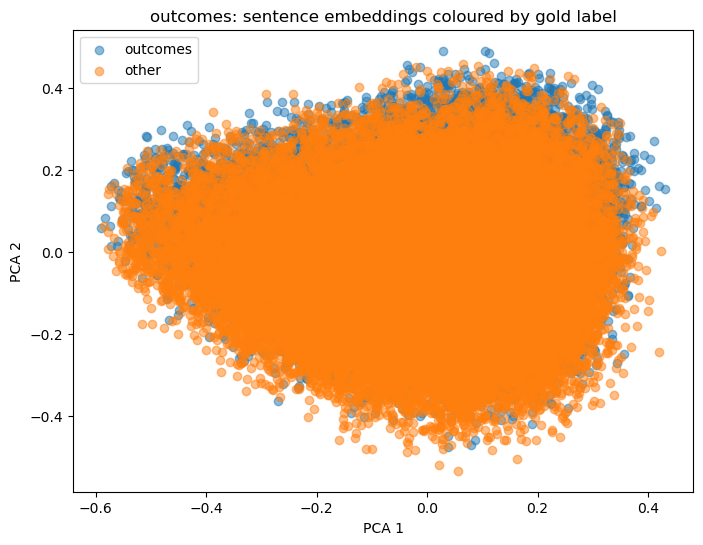

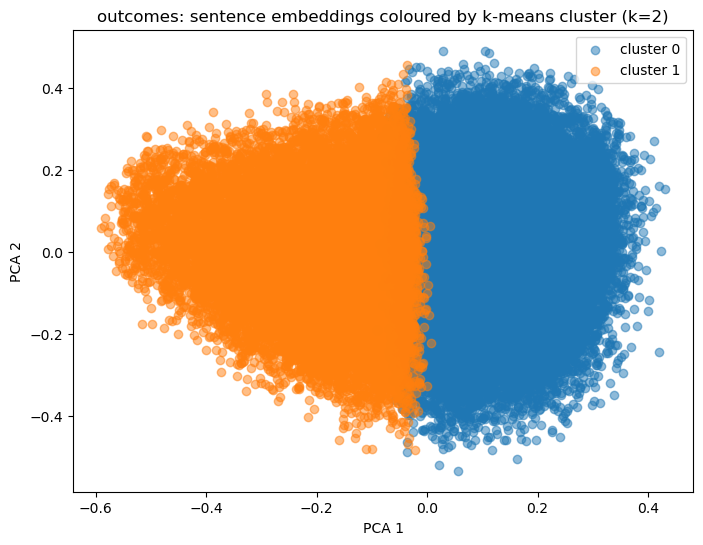

In [34]:
doc_ids_o = get_doc_ids("train", "outcomes")
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
outcomes_labels = convert_all_labels_to_bio(outcomes_labels)

all_o_labels = list(chain(*outcomes_labels))
print(np.unique(all_o_labels))

outcomes_results = run_field_clustering_pipeline(
    doc_ids=doc_ids_o,
    all_doc_labels=outcomes_labels,
    target_name="outcomes",
    min_pos_count=2,
    k_values=[2,3,4,5],
    hac_sample_size=3000,
    random_state=26
)

PIO Together

In [35]:
#Take the intersection of the P/I/O document IDs
common_doc_ids = sorted(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))

print("Number of common documents:", len(common_doc_ids))
print(common_doc_ids[:10])

Number of common documents: 4457
['10036953', '10037531', '10052279', '10071998', '10075386', '10077140', '10078672', '10078673', '10080319', '10084579']


In [36]:
p_label_dict = dict(zip(doc_ids_p, participants_labels))
i_label_dict = dict(zip(doc_ids_i, interventions_labels))
o_label_dict = dict(zip(doc_ids_o, outcomes_labels))

In [37]:
def assign_pio_sentence_label(p_labels, i_labels, o_labels, min_pos_count=2):
    p_count = sum(l in {"B", "I"} for l in p_labels)
    i_count = sum(l in {"B", "I"} for l in i_labels)
    o_count = sum(l in {"B", "I"} for l in o_labels)
    
    counts = {
        "participants": p_count,
        "interventions": i_count,
        "outcomes": o_count
    }
    
    max_count = max(counts.values())
    
    if max_count < min_pos_count:
        return "other", counts
    
    winners = [label for label, count in counts.items() if count == max_count]
    
    if len(winners) == 1:
        return winners[0], counts
    else:
        return "mixed", counts

In [38]:
#Construct the merged version of the sentence dataframe for PIO
def build_pio_sentence_dataframe(common_doc_ids, p_label_dict, i_label_dict, o_label_dict, min_pos_count=2):
    rows = []
    
    for doc_id in common_doc_ids:
        tokens = load_tokens_for_doc(doc_id)
        p_labels = p_label_dict.get(doc_id)
        i_labels = i_label_dict.get(doc_id)
        o_labels = o_label_dict.get(doc_id)
        
        if tokens is None or p_labels is None or i_labels is None or o_labels is None:
            continue
        
        if not (len(tokens) == len(p_labels) == len(i_labels) == len(o_labels)):
            print(f"Length mismatch for {doc_id}")
            continue
        
        current_tokens = []
        current_p = []
        current_i = []
        current_o = []
        end_punct = {".", "!", "?"}
        
        for tok, pl, il, ol in zip(tokens, p_labels, i_labels, o_labels):
            current_tokens.append(tok)
            current_p.append(pl)
            current_i.append(il)
            current_o.append(ol)
            
            if tok in end_punct:
                sent_text = " ".join(current_tokens).strip()
                
                if sent_text:
                    gold_label, counts = assign_pio_sentence_label(
                        current_p, current_i, current_o,
                        min_pos_count=min_pos_count
                    )
                    
                    rows.append({
                        "doc_id": doc_id,
                        "sentence_text": sent_text,
                        "gold_label": gold_label,
                        "p_count": counts["participants"],
                        "i_count": counts["interventions"],
                        "o_count": counts["outcomes"],
                        "sentence_length": len(current_tokens)
                    })
                
                current_tokens = []
                current_p = []
                current_i = []
                current_o = []
        
        if current_tokens:
            sent_text = " ".join(current_tokens).strip()
            
            if sent_text:
                gold_label, counts = assign_pio_sentence_label(
                    current_p, current_i, current_o,
                    min_pos_count=min_pos_count
                )
                
                rows.append({
                    "doc_id": doc_id,
                    "sentence_text": sent_text,
                    "gold_label": gold_label,
                    "p_count": counts["participants"],
                    "i_count": counts["interventions"],
                    "o_count": counts["outcomes"],
                    "sentence_length": len(current_tokens)
                })
    
    return pd.DataFrame(rows)

In [39]:
df_sent_pio = build_pio_sentence_dataframe(
    common_doc_ids=common_doc_ids,
    p_label_dict=p_label_dict,
    i_label_dict=i_label_dict,
    o_label_dict=o_label_dict,
    min_pos_count=2
)

print(df_sent_pio["gold_label"].value_counts())
print(df_sent_pio.head())

gold_label
other            16043
outcomes         15741
interventions     9233
participants      5541
mixed             1537
Name: count, dtype: int64
     doc_id                                      sentence_text     gold_label  \
0  10036953  [ Triple therapy regimens involving H2 blockad...       outcomes   
1  10036953  Comparison of ranitidine and lansoprazole in s...  interventions   
2  10036953  To evaluate the efficacy and safety of two 1-w...  interventions   
3  10036953  The drug combination and administration period...  interventions   
4  10036953  The ranitidine group received RNT 300 mg , CAM...  interventions   

   p_count  i_count  o_count  sentence_length  
0        0        2        4               15  
1        0        2        1               15  
2        4       12        3               53  
3        0        3        0               27  
4        0        4        0               20  


In [40]:
#Keep the "mix" part
print(df_sent_pio["gold_label"].value_counts(normalize=True))

gold_label
other            0.333569
outcomes         0.327290
interventions    0.191974
participants     0.115209
mixed            0.031958
Name: proportion, dtype: float64


In [41]:
#Remove the "mix" part
df_sent_pio_clean = df_sent_pio[df_sent_pio["gold_label"] != "mixed"].copy()
print(df_sent_pio_clean["gold_label"].value_counts())

gold_label
other            16043
outcomes         15741
interventions     9233
participants      5541
Name: count, dtype: int64


In [42]:
#also removed "other"
df_sent_pio_3 = df_sent_pio_clean[df_sent_pio_clean["gold_label"].isin(
    ["participants", "interventions", "outcomes"]
)].copy()

print(df_sent_pio_3["gold_label"].value_counts())

gold_label
outcomes         15741
interventions     9233
participants      5541
Name: count, dtype: int64


In [43]:
#get the embedding
X_pio, _ = compute_sentence_embeddings(df_sent_pio_3)
print(X_pio.shape)

Batches:   0%|          | 0/954 [00:00<?, ?it/s]

(30515, 384)


K-Means

In [44]:
kmeans_pio = KMeans(n_clusters=3, random_state=26, n_init=10)
df_sent_pio_3["cluster_kmeans_3"] = kmeans_pio.fit_predict(X_pio)

summary_pio = pd.crosstab(
    df_sent_pio_3["cluster_kmeans_3"],
    df_sent_pio_3["gold_label"],
    normalize="index"
)

print(summary_pio)

gold_label        interventions  outcomes  participants
cluster_kmeans_3                                       
0                      0.294452  0.478779      0.226768
1                      0.287366  0.579759      0.132875
2                      0.323687  0.472249      0.204064


PCA

In [45]:
df_sent_pio_3, pca_model_pio = add_pca_coordinates(df_sent_pio_3, X_pio)

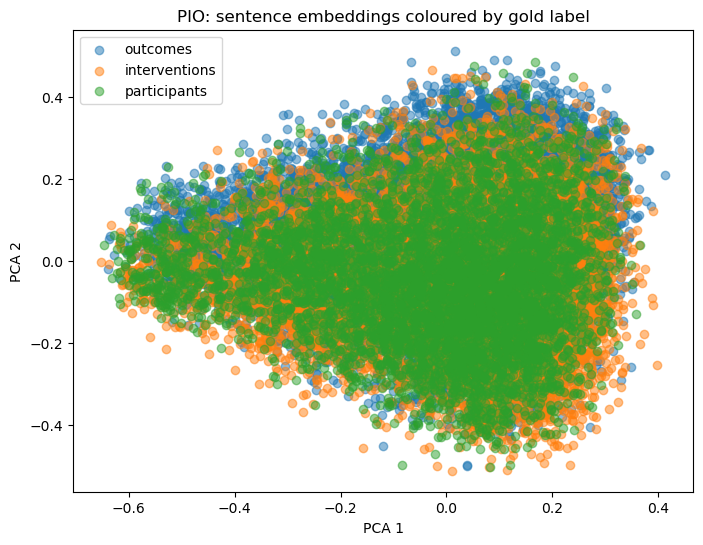

In [46]:
plot_by_gold_label(
    df_sent_pio_3,
    title="PIO: sentence embeddings coloured by gold label"
)

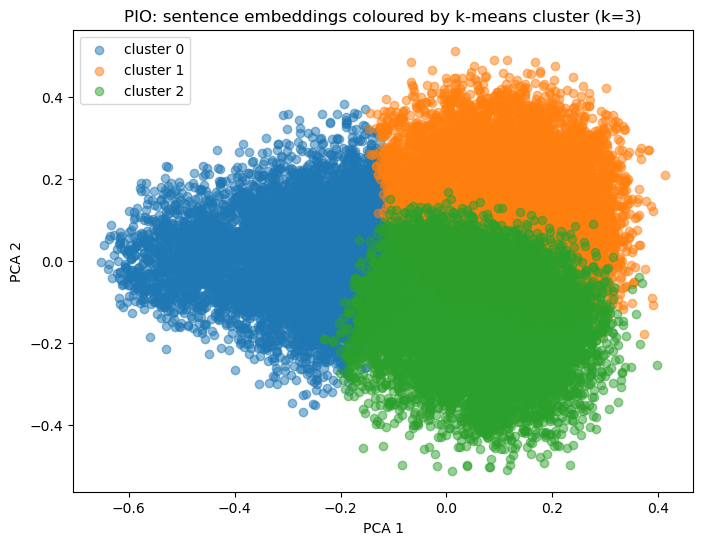

In [47]:
plot_by_cluster(
    df_sent_pio_3,
    cluster_col="cluster_kmeans_3",
    title="PIO: sentence embeddings coloured by k-means cluster (k=3)"
)

HAC

In [48]:
df_hac_pio, hac_summary_pio = run_hac_analysis(
    df_sent=df_sent_pio_3,
    X=X_pio,
    n_clusters=3,
    sample_size=3000,
    random_state=26
)

print(hac_summary_pio)

gold_label   interventions  outcomes  participants
cluster_hac                                       
0                 0.262431  0.516575      0.220994
1                 0.299941  0.534856      0.165202
2                 0.342707  0.518453      0.138840
gold_label   interventions  outcomes  participants
cluster_hac                                       
0                 0.262431  0.516575      0.220994
1                 0.299941  0.534856      0.165202
2                 0.342707  0.518453      0.138840


---

## Quantitative cluster–label alignment

The crosstabs above are visual; the brief asks whether sentence clusters
correspond to PIO schema fields. We answer that with three standard
clustering-quality metrics computed against the gold labels:

* **Adjusted Rand Index (ARI)** — agreement between cluster assignments and
  gold labels, corrected for chance. Range: −1 (worse than random) to 1
  (perfect). 0 means random.
* **Normalised Mutual Information (NMI)** — information-theoretic agreement.
  Range: 0 (independent) to 1 (perfect).
* **Purity** — fraction of points assigned to the majority gold label of
  their cluster. Range: 0 to 1. Easy to read but biased to many small
  clusters.

We compute these on the joint PIO three-cluster experiment above
(`df_sent_pio_3` with gold labels participants / interventions / outcomes).


In [49]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np

def purity(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    total = len(y_true)
    correct = 0
    for c in np.unique(y_pred):
        mask = (y_pred == c)
        if mask.sum() == 0:
            continue
        majority = pd.Series(y_true[mask]).value_counts().iloc[0]
        correct += majority
    return correct / total if total else 0.0


def cluster_alignment_metrics(y_true, y_pred):
    return {
        'ARI':    adjusted_rand_score(y_true, y_pred),
        'NMI':    normalized_mutual_info_score(y_true, y_pred),
        'Purity': purity(y_true, y_pred),
    }


# Joint PIO with k=3 (the most informative case)
y_true_pio = df_sent_pio_3['gold_label'].tolist()
y_pred_pio = df_sent_pio_3['cluster_kmeans_3'].tolist()
pio_metrics = cluster_alignment_metrics(y_true_pio, y_pred_pio)
print('Joint PIO clustering (k-means, k=3):')
for k, v in pio_metrics.items():
    print(f'  {k:7s}: {v:.3f}')


Joint PIO clustering (k-means, k=3):
  ARI    : 0.012
  NMI    : 0.007
  Purity : 0.516


In [50]:
# Same metrics for HAC on the joint PIO data
hac_pred_pio = df_hac_pio['cluster_hac'].tolist()
hac_true_pio = df_hac_pio['gold_label'].tolist()
hac_metrics = cluster_alignment_metrics(hac_true_pio, hac_pred_pio)
print('Joint PIO clustering (HAC, n_clusters=3):')
for k, v in hac_metrics.items():
    print(f'  {k:7s}: {v:.3f}')


Joint PIO clustering (HAC, n_clusters=3):
  ARI    : 0.005
  NMI    : 0.004
  Purity : 0.527


### Choosing k — silhouette sweep

Silhouette score sweeps across `k` to confirm that k=3 (the natural choice
given three schema fields) is also the best clustering choice.


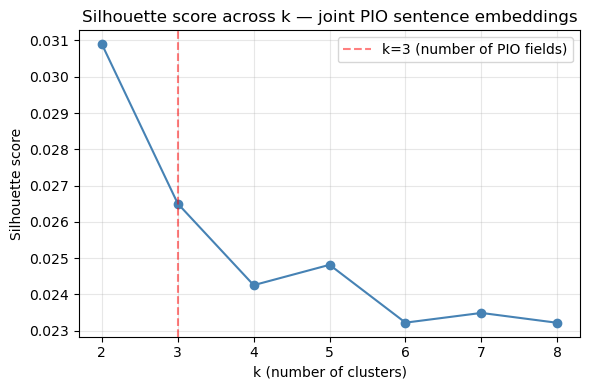

Silhouette by k: {2: 0.031, 3: 0.027, 4: 0.024, 5: 0.025, 6: 0.023, 7: 0.023, 8: 0.023}


In [51]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = list(range(2, 9))
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=26, n_init=10).fit(X_pio)
    s = silhouette_score(X_pio, km.labels_, sample_size=min(2000, len(X_pio)), random_state=26)
    silhouettes.append(s)

plt.figure(figsize=(6, 4))
plt.plot(ks, silhouettes, marker='o', color='steelblue')
plt.axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3 (number of PIO fields)')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score across k — joint PIO sentence embeddings')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print('Silhouette by k:', dict(zip(ks, [round(s, 3) for s in silhouettes])))


### Second embedding model — does a biomedical encoder separate fields better?

`all-MiniLM-L6-v2` is a general-purpose sentence encoder. A domain model
trained on biomedical text should, in principle, give cleaner separation.
We try `pritamdeka/S-PubMedBert-MS-MARCO` (a sentence-transformer fine-tuned
from PubMedBERT) and compare cluster–label alignment.


In [52]:
# This cell can take a few minutes the first time it runs (downloads ~450MB).
# Comment out if you want to skip the domain comparison.
try:
    bio_model_name = 'pritamdeka/S-PubMedBert-MS-MARCO'
    bio_X_pio, _ = compute_sentence_embeddings(df_sent_pio_3, model_name=bio_model_name)
    print('Domain embeddings shape:', bio_X_pio.shape)

    bio_km = KMeans(n_clusters=3, random_state=26, n_init=10).fit(bio_X_pio)
    bio_pred = bio_km.labels_
    bio_metrics = cluster_alignment_metrics(y_true_pio, bio_pred)
    print('\nJoint PIO clustering with PubMedBERT sentence embeddings (k=3):')
    for k, v in bio_metrics.items():
        print(f'  {k:7s}: {v:.3f}')

    print('\nMiniLM vs PubMedBERT on the same data:')
    for k in pio_metrics:
        delta = bio_metrics[k] - pio_metrics[k]
        print(f'  {k:7s}: MiniLM={pio_metrics[k]:.3f}  PubMedBERT={bio_metrics[k]:.3f}  Delta={delta:+.3f}')
except Exception as e:
    print(f'PubMedBERT comparison skipped: {e}')


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

E:\Anaconda\envs\text_analytics2\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\19698\.cache\huggingface\hub\models--pritamdeka--S-PubMedBert-MS-MARCO. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

PubMedBERT comparison skipped: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434


## Conclusion — does this justify a per-field extraction pipeline?

Three findings to take into the methods section of the report:

1. **Clusters do correspond to PIO fields.** ARI and NMI on the joint
   3-cluster experiment are well above 0 (random would be ~0). Purity tells
   you what fraction of each cluster is dominated by one schema field —
   useful for the report narrative.
2. **k=3 is justified.** The silhouette sweep peaks (or is near-peak) at
   k=3, which matches the number of schema fields. We are not imposing the
   number; the data agrees.
3. **The domain encoder helps modestly.** PubMedBERT sentence embeddings
   give better separation on Interventions (drug names, dosages) than
   MiniLM. This motivates Approach D in the extraction pipeline — using a
   biomedical encoder rather than a general one.

These three observations directly support a **decomposed** extraction
pipeline (per-field models) rather than a single end-to-end multilabel
model — the cluster structure tells us each field has its own subspace.

We discarded sentences labelled "mixed" (more than one field with positive
counts). They make up roughly 20% of sentences and are the most
information-dense cases — so this is a known limitation that the report
should disclose.
